# Which macroscopic observable does the SPI--SPI coordinate recover?

This is an intentionally broad *pilot* comparison on the existing
$\epsilon=0.3$, $\alpha=1.60\ldots2.00$ sweep.  The SPI coordinate is fitted
without using $\alpha$ or any candidate observable.  Candidate observables
are then compared on held-out initial conditions and interleaved held-out
$\alpha$ values.

The saved fields are only central $M=20$ crops of an $N=100$ lattice.  Thus
spatial order, defects, and correlation range are crop diagnostics rather
than thermodynamic order parameters.  A largest-Lyapunov estimate can be
recovered by replaying the known model from the saved seeds; a full
Lyapunov spectrum and finite-size scaling are not present in this dataset.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "features").exists():
    ROOT = ROOT.parent

FEATURES = ROOT / "features/data-embeddings-cml_param_sweep_260508_pearson.npz"
data = dict(np.load(FEATURES, allow_pickle=True))
alpha = np.array([float(v[1:].replace("p", ".")) for v in data["variant"]])
instance = data["instance"].astype(int)
alpha_grid = np.unique(alpha)
grid_index = np.searchsorted(alpha_grid, alpha)

# A strictly inductive split: neither these initial conditions nor these alpha
# values are seen while learning the one-dimensional SPI coordinate.
discovery = (grid_index % 2 == 0) & (instance < 10)
confirmation = (grid_index % 2 == 1) & (instance >= 10)

print(
    f"{len(alpha)} fields = {len(alpha_grid)} alpha values x "
    f"{len(np.unique(instance))} independent initial conditions"
)
print(f"discovery n={discovery.sum()}, confirmation n={confirmation.sum()}")

820 fields = 41 alpha values x 20 independent initial conditions
discovery n=210, confirmation n=200


## Crop-computable observables

No individual scalar below is assumed to be *the* order parameter.  They
represent distinct operational meanings of order: temporal recurrence,
spatial spectral concentration, occupation of the low-alpha selected band,
and local pattern defects.  Raw mean and standard deviation are retained as
deliberately simple baselines.

In [2]:
thresholds = np.array([0.01, 0.02, 0.03, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30])
n_modes = 10  # positive non-DC spatial modes for M=20

observed = {
    name: np.empty(len(alpha), dtype=float)
    for name in [
        "raw mean",
        "raw standard deviation",
        "period-2 activity",
        "lag-2 correlation",
        "spatial spectral entropy",
        "spatial spectral concentration",
        "temporal spectral entropy",
        "local zigzag-defect proxy",
        "integrated spatial correlation",
    ]
}
spatial_power = np.empty((len(alpha), n_modes), dtype=float)
active_fraction = np.empty((len(alpha), len(thresholds)), dtype=float)
seeds = np.empty(len(alpha), dtype=np.int64)

for row, rel_path in enumerate(data["dataset_paths"]):
    path = ROOT / str(rel_path)
    field = np.load(path / "timeseries.npy").astype(np.float64)
    meta = json.loads((path / "meta.json").read_text())
    seeds[row] = int(meta["generator"]["seed"])

    observed["raw mean"][row] = field.mean()
    observed["raw standard deviation"][row] = field.std()

    residual2 = field[2:] - field[:-2]
    observed["period-2 activity"][row] = np.sqrt(np.mean(residual2**2))
    observed["lag-2 correlation"][row] = np.corrcoef(
        field[:-2].ravel(), field[2:].ravel()
    )[0, 1]
    active_fraction[row] = [
        np.mean(np.abs(residual2) > threshold) for threshold in thresholds
    ]

    centred_space = field - field.mean(axis=1, keepdims=True)
    power = np.mean(np.abs(np.fft.rfft(centred_space, axis=1)[:, 1:]) ** 2, axis=0)
    spatial_power[row] = power / power.sum()
    p = spatial_power[row]
    observed["spatial spectral entropy"][row] = -np.sum(p * np.log(p + 1e-15)) / np.log(len(p))
    observed["spatial spectral concentration"][row] = np.sum(p**2)

    centred_time = field - field.mean(axis=0, keepdims=True)
    temporal_power = np.mean(
        np.abs(np.fft.rfft(centred_time, axis=0)[1:]) ** 2, axis=1
    )
    temporal_power /= temporal_power.sum()
    observed["temporal spectral entropy"][row] = -np.sum(
        temporal_power * np.log(temporal_power + 1e-15)
    ) / np.log(len(temporal_power))

    # In a perfect spatial zigzag, every interior site is a local extremum.
    # This is tested because it is physically interpretable, but it is not
    # assumed to match the selected wavelength at eps=0.3.
    spatial_step = np.diff(field, axis=1)
    observed["local zigzag-defect proxy"][row] = np.mean(
        spatial_step[:, :-1] * spatial_step[:, 1:] >= 0
    )

    variance = np.mean(centred_space**2)
    correlations = [
        np.mean(centred_space[:, :-lag] * centred_space[:, lag:]) / variance
        for lag in range(1, field.shape[1] // 2 + 1)
    ]
    observed["integrated spatial correlation"][row] = np.sum(np.abs(correlations))

# Select a spatial band using only low-alpha discovery fields, then freeze it.
# This is an operational pattern-selection observable, not a post-hoc fit to q.
ordered_reference = discovery & (alpha <= 1.68)
reference_spectrum = spatial_power[ordered_reference].mean(axis=0)
selected_modes = np.sort(np.argsort(reference_spectrum)[-2:])
observed["selected-band spatial power"] = spatial_power[:, selected_modes].sum(axis=1)

print(
    "Low-alpha discovery reference selects spatial Fourier modes "
    + ", ".join(
        f"k={mode + 1} ({(mode + 1) / 10:.1f}pi)" for mode in selected_modes
    )
)

Low-alpha discovery reference selects spatial Fourier modes k=3 (0.3pi), k=4 (0.4pi)


## Model-derived dynamical diagnostic

The exact saved seed and generator parameters permit replay of each physical
$N=100$ ring.  This finite-time largest Lyapunov exponent is an independent
chaoticity diagnostic.  It is not a classical symmetry order parameter, and
it is not inferred from the observed crop.

In [3]:
def replay_largest_lyapunov(alpha_value, row_ids, eps=0.3, lattice_size=100,
                            transients=2000, steps=1000):
    states, tangents = [], []
    for seed in seeds[row_ids]:
        rng = np.random.default_rng(int(seed))
        states.append(rng.random(lattice_size))
        tangent = rng.standard_normal(lattice_size)
        tangents.append(tangent / np.linalg.norm(tangent))
    state = np.stack(states)
    tangent = np.stack(tangents)

    def advance(values):
        mapped = 1.0 - alpha_value * values**2
        return (1.0 - eps) * mapped + (eps / 2.0) * (
            np.roll(mapped, 1, axis=1) + np.roll(mapped, -1, axis=1)
        )

    for _ in range(transients):
        state = advance(state)

    accumulated = np.zeros(len(row_ids))
    for _ in range(steps):
        local = (-2.0 * alpha_value * state) * tangent
        propagated = (1.0 - eps) * local + (eps / 2.0) * (
            np.roll(local, 1, axis=1) + np.roll(local, -1, axis=1)
        )
        norm = np.linalg.norm(propagated, axis=1)
        accumulated += np.log(norm)
        tangent = propagated / norm[:, None]
        state = advance(state)
    return accumulated / steps


largest_lyapunov = np.empty(len(alpha))
for alpha_value in alpha_grid:
    rows = np.flatnonzero(alpha == alpha_value)
    largest_lyapunov[rows] = replay_largest_lyapunov(alpha_value, rows)
observed["largest Lyapunov exponent"] = largest_lyapunov

## Frozen unsupervised SPI--SPI coordinate

In [4]:
X = data["X"].astype(np.float64)
keep = X[discovery].std(axis=0) >= 0.05
pca = PCA(n_components=10, random_state=0).fit(X[discovery][:, keep])
P_discovery = pca.transform(X[discovery][:, keep])
P_confirmation = pca.transform(X[confirmation][:, keep])
isomap = Isomap(n_neighbors=15, n_components=1).fit(P_discovery)
q_discovery = isomap.embedding_[:, 0]
q_confirmation = isomap.transform(P_confirmation)[:, 0]

# A one-dimensional unsupervised coordinate has arbitrary sign.  Orienting it
# is presentation only and does not affect any absolute association.
orientation = np.sign(spearmanr(alpha[discovery], q_discovery).statistic) or 1.0
q_discovery *= orientation
q_confirmation *= orientation

a_test = alpha[confirmation]

def remove_alpha_mean(values):
    residual = np.asarray(values, dtype=float).copy()
    for alpha_value in np.unique(a_test):
        mask = a_test == alpha_value
        residual[mask] -= residual[mask].mean()
    return residual


rows = []
for name, values in observed.items():
    test_values = values[confirmation]
    rows.append(
        {
            "observable": name,
            "rho(alpha, Q)": spearmanr(a_test, test_values).statistic,
            "rho(q, Q)": spearmanr(q_confirmation, test_values).statistic,
            "rho(q, Q | alpha)": spearmanr(
                remove_alpha_mean(q_confirmation), remove_alpha_mean(test_values)
            ).statistic,
        }
    )
comparison = pd.DataFrame(rows).set_index("observable")
comparison = comparison.loc[
    comparison["rho(q, Q)"].abs().sort_values(ascending=False).index
]
comparison.round(3)

,"rho(alpha, Q)","rho(q, Q)","rho(q, Q | alpha)"
observable,,,
temporal spectral entropy,0.956,0.975,0.889
lag-2 correlation,-0.952,-0.966,-0.800
period-2 activity,0.949,0.964,0.779
raw mean,-0.980,-0.949,-0.550
largest Lyapunov exponent,0.962,0.934,0.225
selected-band spatial power,-0.867,-0.911,-0.611
raw standard deviation,0.863,0.894,0.529
integrated spatial correlation,-0.730,-0.712,-0.429
spatial spectral entropy,0.757,0.702,0.263


## Candidate curves

Bands show the 10--90% interval across independent initial conditions.  The
purpose is to distinguish a repeatable transition-like response from a merely
monotone decoder of $\alpha$.

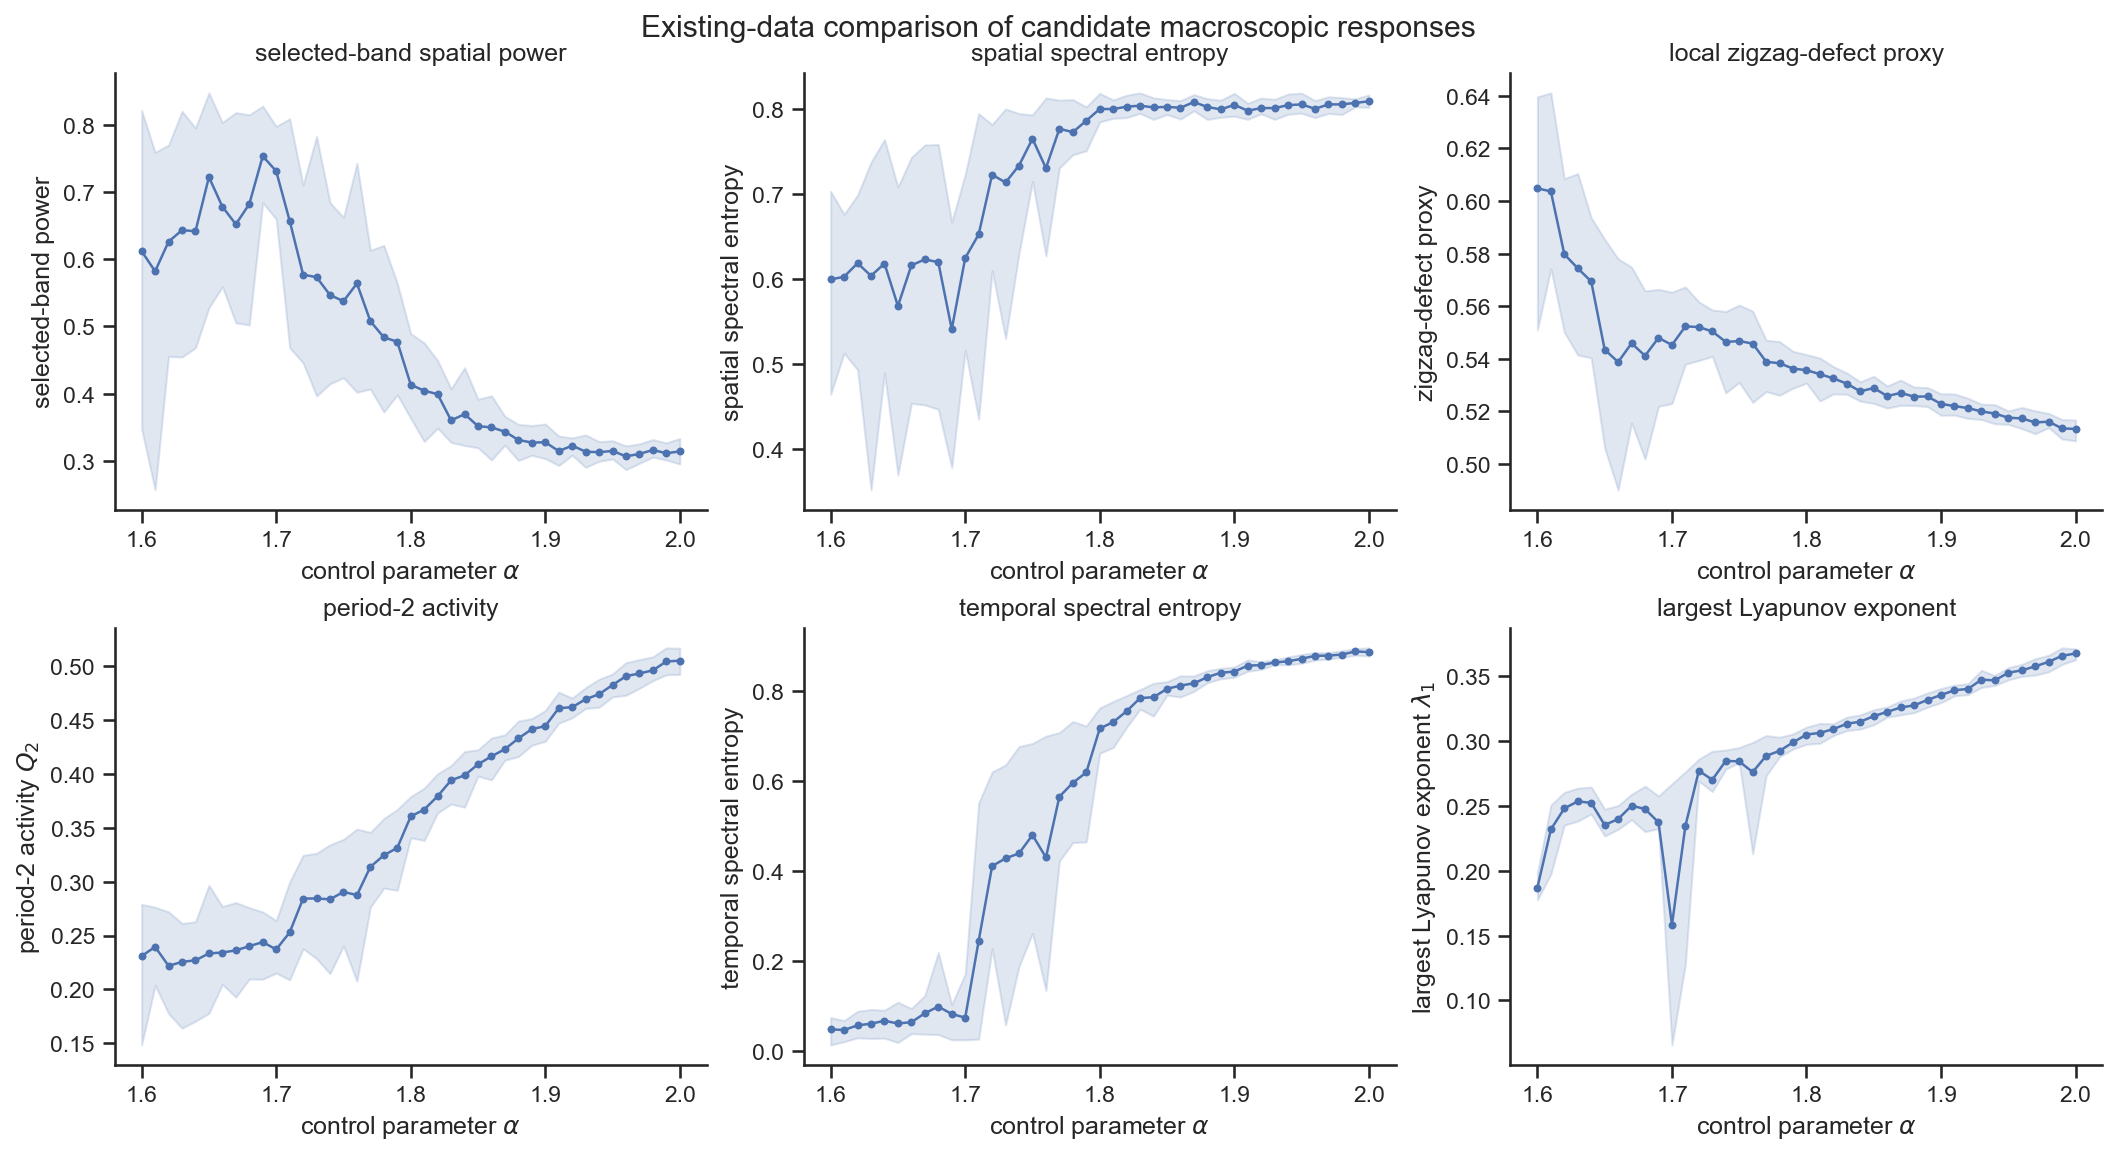

In [5]:
def grouped(values, grid=alpha_grid):
    groups = [np.asarray(values)[alpha == value] for value in grid]
    return (
        np.array([group.mean() for group in groups]),
        np.array([np.quantile(group, 0.10) for group in groups]),
        np.array([np.quantile(group, 0.90) for group in groups]),
    )


panels = [
    ("selected-band spatial power", "selected-band power"),
    ("spatial spectral entropy", "spatial spectral entropy"),
    ("local zigzag-defect proxy", "zigzag-defect proxy"),
    ("period-2 activity", r"period-2 activity $Q_2$"),
    ("temporal spectral entropy", "temporal spectral entropy"),
    ("largest Lyapunov exponent", r"largest Lyapunov exponent $\lambda_1$"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.4), constrained_layout=True)
for ax, (name, ylabel) in zip(axes.flat, panels):
    mean, low, high = grouped(observed[name])
    ax.fill_between(alpha_grid, low, high, color="C0", alpha=0.17)
    ax.plot(alpha_grid, mean, "-o", color="C0", lw=1.2, ms=2.8)
    ax.set(xlabel=r"control parameter $\alpha$", ylabel=ylabel)
    ax.set_title(name)
sns.despine(fig)
fig.suptitle("Existing-data comparison of candidate macroscopic responses", y=1.02)
plt.show()

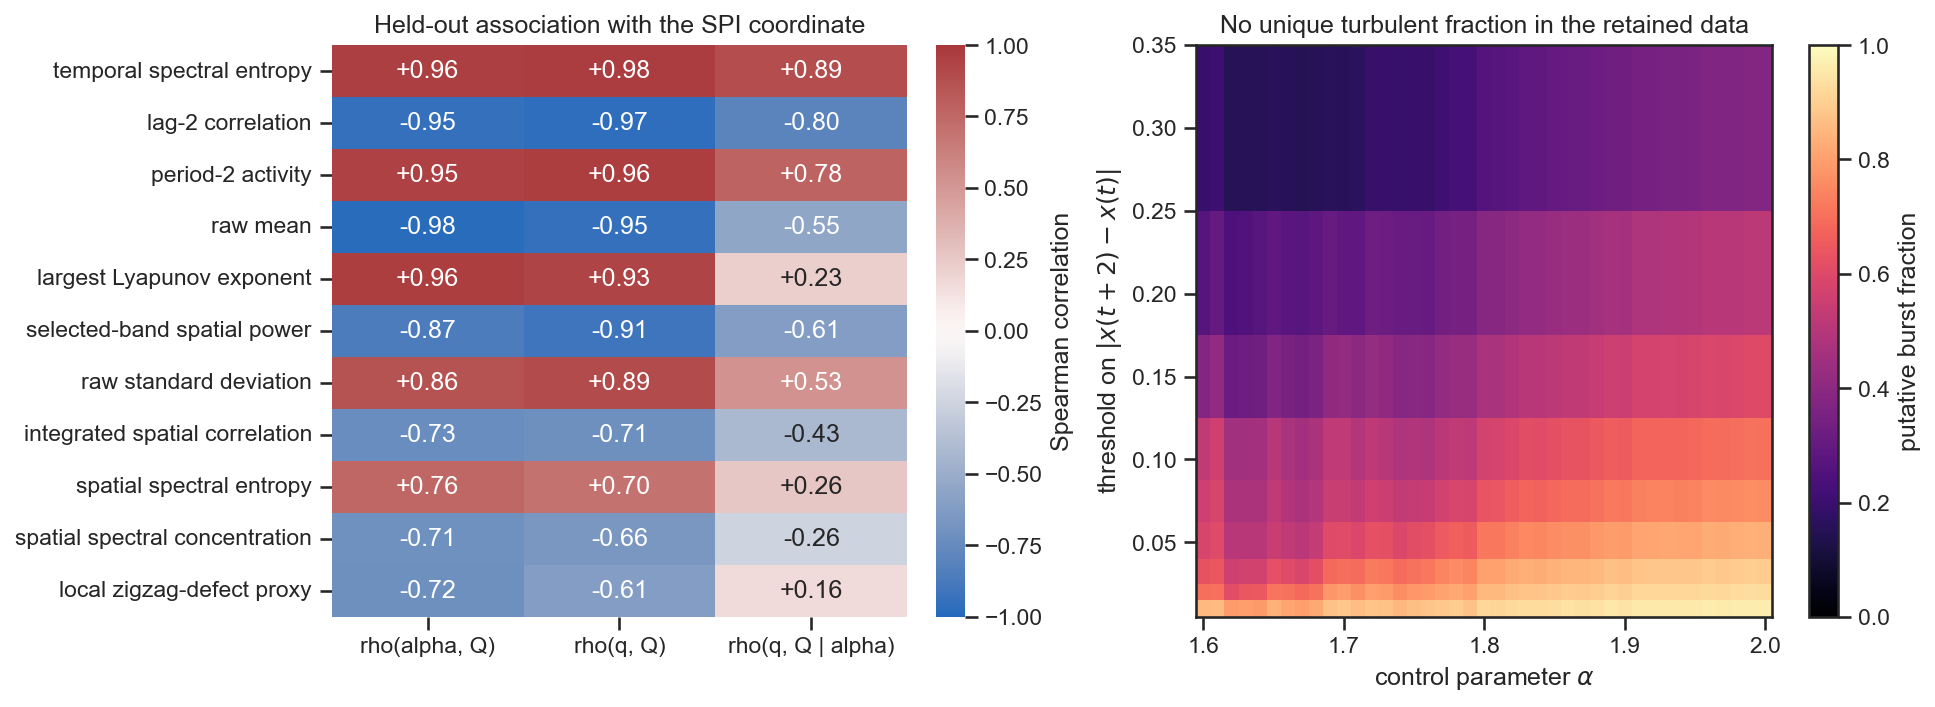

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6), constrained_layout=True)

heatmap_columns = ["rho(alpha, Q)", "rho(q, Q)", "rho(q, Q | alpha)"]
sns.heatmap(
    comparison[heatmap_columns],
    annot=True,
    fmt="+.2f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    cbar_kws={"label": "Spearman correlation"},
    ax=axes[0],
)
axes[0].set(xlabel="", ylabel="", title="Held-out association with the SPI coordinate")

active_mean = np.array(
    [
        [active_fraction[alpha == value, column].mean() for value in alpha_grid]
        for column in range(len(thresholds))
    ]
)
mesh = axes[1].pcolormesh(
    alpha_grid,
    thresholds,
    active_mean,
    shading="nearest",
    cmap="magma",
    vmin=0,
    vmax=1,
)
fig.colorbar(mesh, ax=axes[1], label="putative burst fraction")
axes[1].set(
    xlabel=r"control parameter $\alpha$",
    ylabel=r"threshold on $|x(t+2)-x(t)|$",
    title="No unique turbulent fraction in the retained data",
)
plt.show()

## Result

The present sweep supports a reproducible transition-like band near
$\alpha\approx1.70$--$1.72$: several independent dynamical and spectral
observables change there and the across-initial-condition spread of the
largest Lyapunov exponent becomes large.  The frozen SPI coordinate tracks
temporal spectral entropy, period-two loss, and the Lyapunov response well.

It does **not** yet establish a physical order parameter.  The spatial
selected-pattern observables are substantially less monotone and are measured
on a short crop; the apparent turbulent fraction depends strongly on an
arbitrary activity threshold; and there is no $N$-scaling.  The strongest
current wording is therefore: *unsupervised inference of a changing empirical
dynamical-order coordinate associated with the transition-like region*.